# Visualizations

**Purpose:** Custom charts and figures for the CBL-16 report and presentation.

**Data sources:** Outputs from phases 1–5 in `outputs/`

**Outputs saved to:** `outputs/vizu/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

BASE = Path(r'C:\Users\mbeck\OneDrive\Documents\CBL-16_data')
OUT  = BASE / 'outputs' / 'vizu'
P1   = BASE / 'outputs' / 'phase1'
P2   = BASE / 'outputs' / 'phase2'
P5   = BASE / 'outputs' / 'phase5'

TIER_COLOURS = {1: '#D62728', 2: '#FF7F0E', 3: '#2CA02C', 4: '#1F77B4'}
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})
print('Ready. Output folder:', OUT)

Ready. Output folder: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\vizu


## Visualization 1 — Crime per Month (3 lines, one per year)

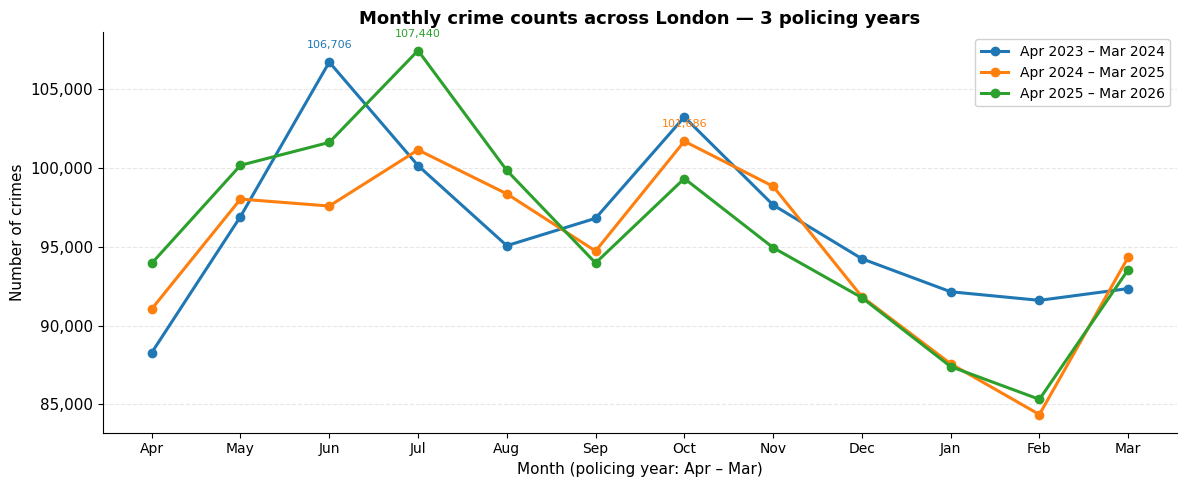

Saved: v1_crime_per_month.png


In [2]:
crimes = pd.read_parquet(P1 / 'phase1_crimes_london.parquet')
crimes['Month'] = pd.to_datetime(crimes['Month'])

monthly = crimes.groupby('Month').size().reset_index(name='count')
monthly['month_num'] = monthly['Month'].dt.month  # 1-12 for x-axis
monthly['year']      = monthly['Month'].dt.year

# Split into 3 policing years (Apr–Mar)
# Year 1: Apr 2023 – Mar 2024
# Year 2: Apr 2024 – Mar 2025
# Year 3: Apr 2025 – Mar 2026
def policing_year(row):
    if pd.Timestamp('2023-04-01') <= row['Month'] <= pd.Timestamp('2024-03-01'):
        return 'Apr 2023 – Mar 2024'
    elif pd.Timestamp('2024-04-01') <= row['Month'] <= pd.Timestamp('2025-03-01'):
        return 'Apr 2024 – Mar 2025'
    else:
        return 'Apr 2025 – Mar 2026'

monthly['pol_year'] = monthly.apply(policing_year, axis=1)

# Re-order months so April = 1 ... March = 12
month_order  = [4,5,6,7,8,9,10,11,12,1,2,3]
month_labels = ['Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar']
monthly['month_pos'] = monthly['month_num'].apply(lambda m: month_order.index(m) + 1)

year_colours = {
    'Apr 2023 – Mar 2024': '#1F77B4',
    'Apr 2024 – Mar 2025': '#FF7F0E',
    'Apr 2025 – Mar 2026': '#2CA02C',
}

fig, ax = plt.subplots(figsize=(12, 5))

for yr, grp in monthly.groupby('pol_year'):
    grp = grp.sort_values('month_pos')
    ax.plot(grp['month_pos'], grp['count'],
            marker='o', linewidth=2.2, markersize=6,
            color=year_colours[yr], label=yr)
    # Annotate peak month
    peak = grp.loc[grp['count'].idxmax()]
    ax.annotate(f"{int(peak['count']):,}",
                xy=(peak['month_pos'], peak['count']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8,
                color=year_colours[yr])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Month (policing year: Apr – Mar)', fontsize=11)
ax.set_ylabel('Number of crimes', fontsize=11)
ax.set_title('Monthly crime counts across London — 3 policing years', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUT / 'v1_crime_per_month.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v1_crime_per_month.png')

## Visualization 2 — Dataset Summary Cards (one per dataset)

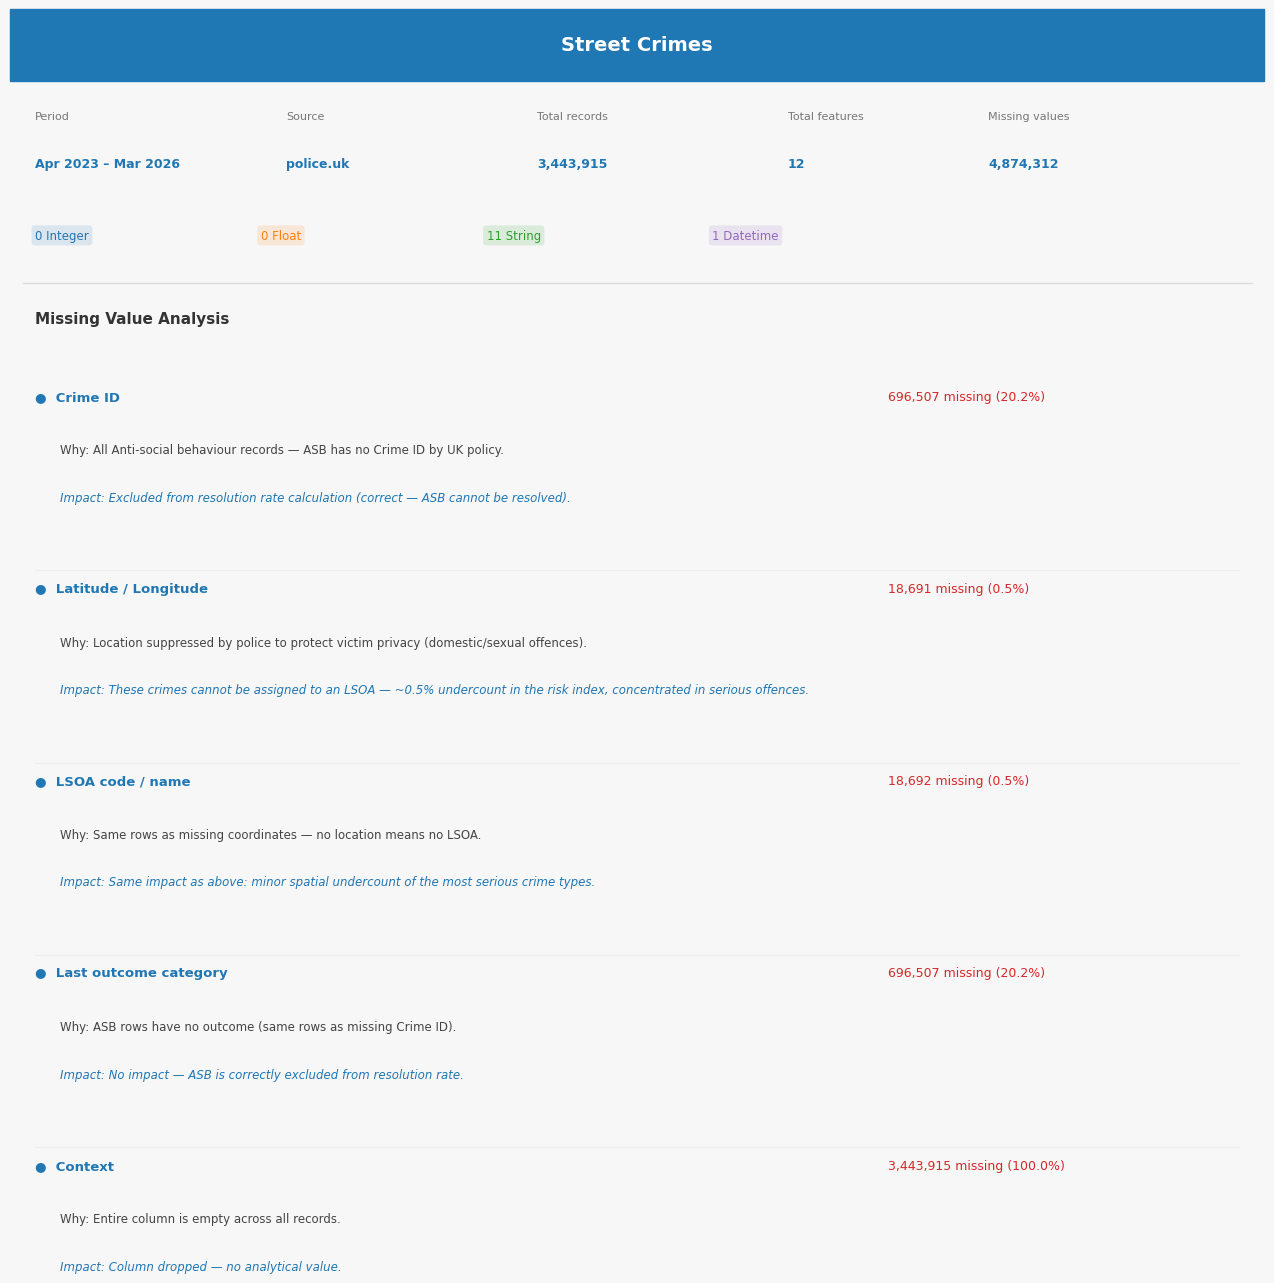

Saved: v2_street_crimes.png


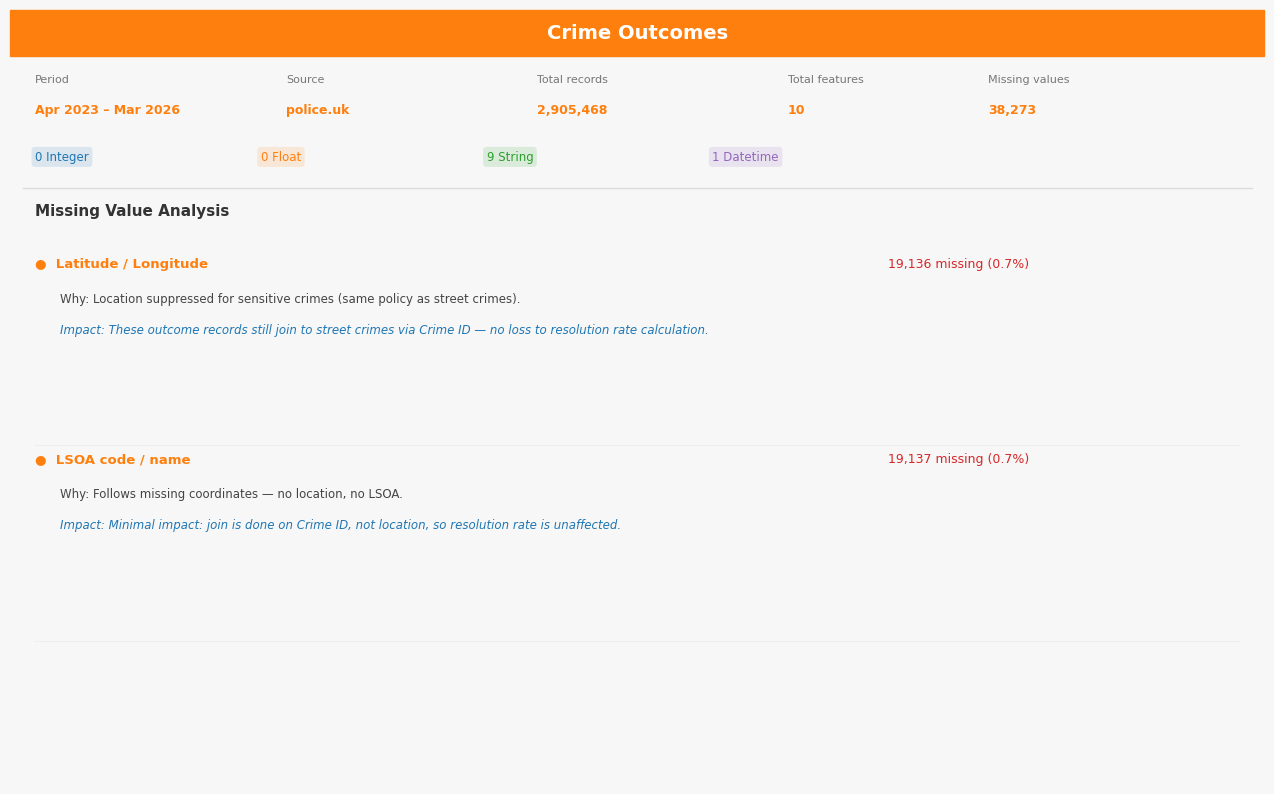

Saved: v2_crime_outcomes.png


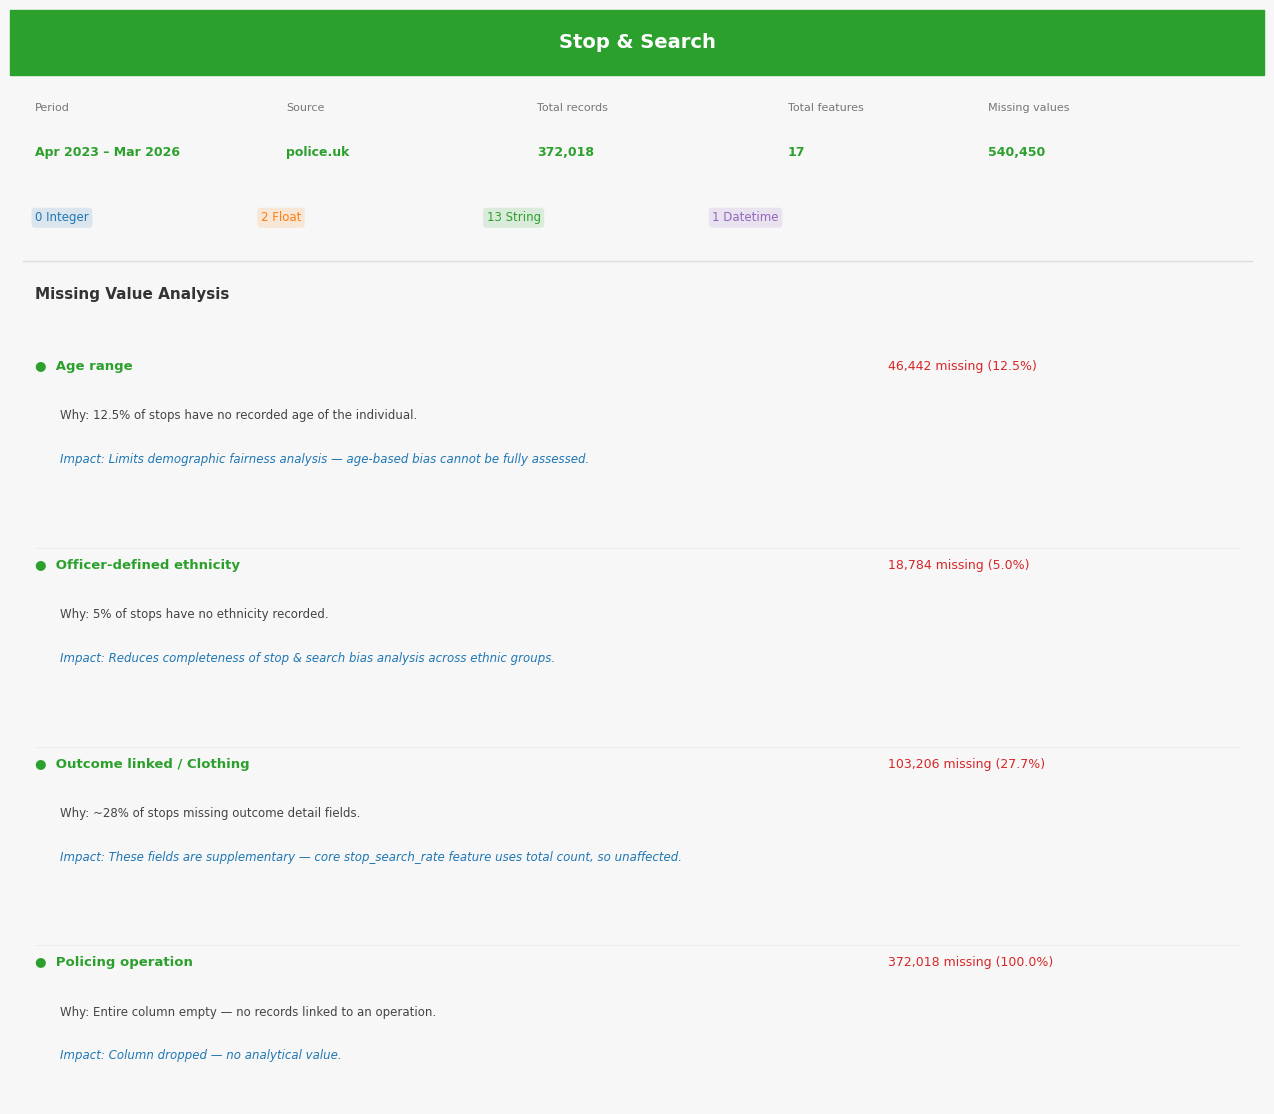

Saved: v2_stop_&_search.png


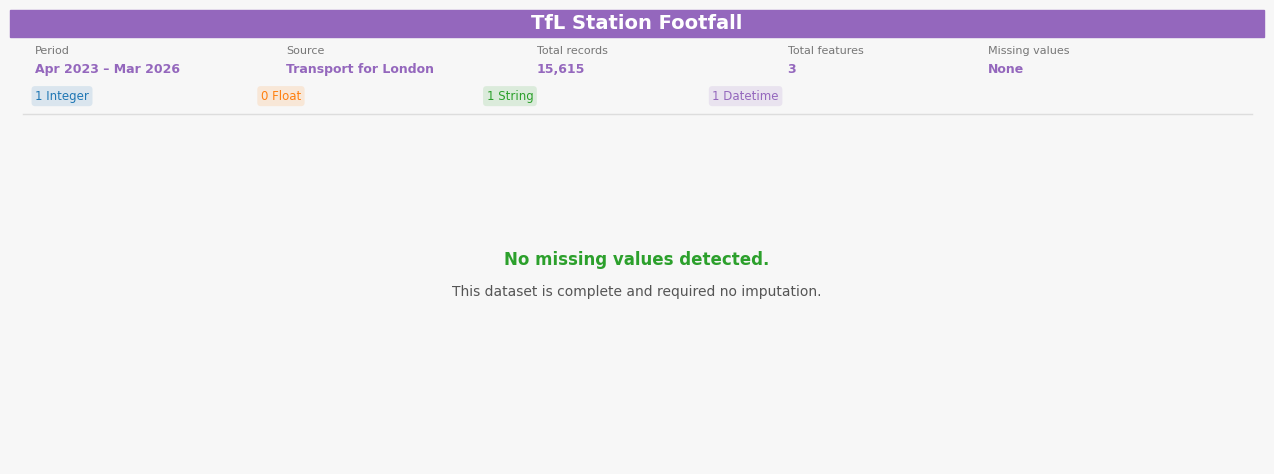

Saved: v2_tfl_station_footfall.png


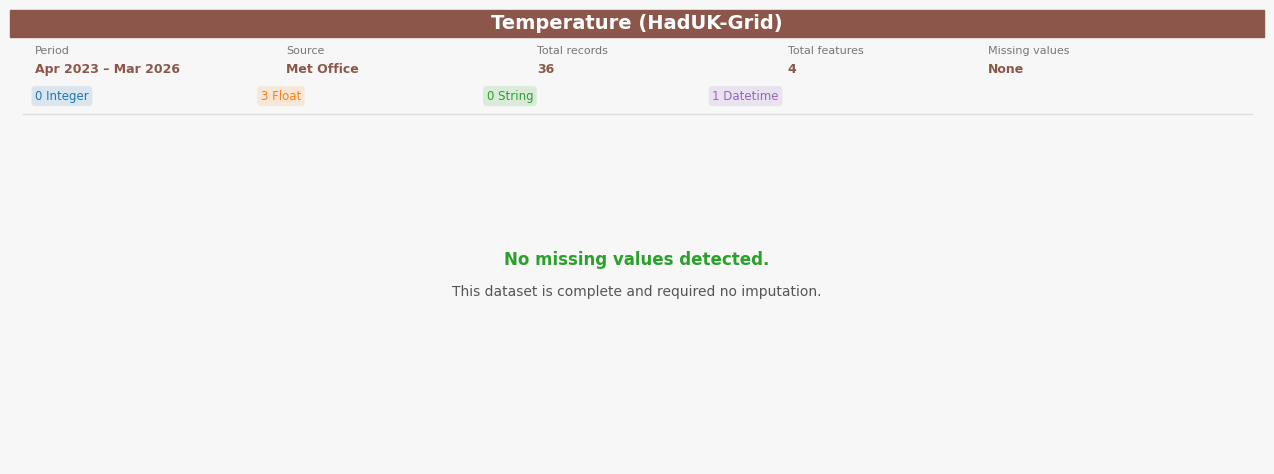

Saved: v2_temperature_hadukgrid.png


In [3]:
datasets = [
    {
        'name':     'Street Crimes',
        'source':   'police.uk',
        'colour':   '#1F77B4',
        'rows':     3_443_915,
        'features': 12,
        'dtypes':   {'Integer': 0, 'Float': 0, 'String': 11, 'Datetime': 1},
        'missing': [
            ('Crime ID',               696_507, 'All Anti-social behaviour records — ASB has no Crime ID by UK policy.',
             'Excluded from resolution rate calculation (correct — ASB cannot be resolved).'),
            ('Latitude / Longitude',    18_691, 'Location suppressed by police to protect victim privacy (domestic/sexual offences).',
             'These crimes cannot be assigned to an LSOA — ~0.5% undercount in the risk index, concentrated in serious offences.'),
            ('LSOA code / name',        18_692, 'Same rows as missing coordinates — no location means no LSOA.',
             'Same impact as above: minor spatial undercount of the most serious crime types.'),
            ('Last outcome category',  696_507, 'ASB rows have no outcome (same rows as missing Crime ID).',
             'No impact — ASB is correctly excluded from resolution rate.'),
            ('Context',              3_443_915, 'Entire column is empty across all records.',
             'Column dropped — no analytical value.'),
        ],
    },
    {
        'name':     'Crime Outcomes',
        'source':   'police.uk',
        'colour':   '#FF7F0E',
        'rows':     2_905_468,
        'features': 10,
        'dtypes':   {'Integer': 0, 'Float': 0, 'String': 9, 'Datetime': 1},
        'missing': [
            ('Latitude / Longitude',   19_136, 'Location suppressed for sensitive crimes (same policy as street crimes).',
             'These outcome records still join to street crimes via Crime ID — no loss to resolution rate calculation.'),
            ('LSOA code / name',       19_137, 'Follows missing coordinates — no location, no LSOA.',
             'Minimal impact: join is done on Crime ID, not location, so resolution rate is unaffected.'),
        ],
    },
    {
        'name':     'Stop & Search',
        'source':   'police.uk',
        'colour':   '#2CA02C',
        'rows':     372_018,
        'features': 17,
        'dtypes':   {'Integer': 0, 'Float': 2, 'String': 13, 'Datetime': 1},
        'missing': [
            ('Age range',               46_442, '12.5% of stops have no recorded age of the individual.',
             'Limits demographic fairness analysis — age-based bias cannot be fully assessed.'),
            ('Officer-defined ethnicity',18_784, '5% of stops have no ethnicity recorded.',
             'Reduces completeness of stop & search bias analysis across ethnic groups.'),
            ('Outcome linked / Clothing',103_206,'~28% of stops missing outcome detail fields.',
             'These fields are supplementary — core stop_search_rate feature uses total count, so unaffected.'),
            ('Policing operation',      372_018, 'Entire column empty — no records linked to an operation.',
             'Column dropped — no analytical value.'),
        ],
    },
    {
        'name':     'TfL Station Footfall',
        'source':   'Transport for London',
        'colour':   '#9467BD',
        'rows':     15_615,
        'features': 3,
        'dtypes':   {'Integer': 1, 'Float': 0, 'String': 1, 'Datetime': 1},
        'missing': [],
    },
    {
        'name':     'Temperature (HadUK-Grid)',
        'source':   'Met Office',
        'colour':   '#8C564B',
        'rows':     36,
        'features': 4,
        'dtypes':   {'Integer': 0, 'Float': 3, 'String': 0, 'Datetime': 1},
        'missing': [],
    },
]

def make_dataset_card(ds, save_path):
    has_missing = len(ds['missing']) > 0
    n_missing_blocks = len(ds['missing'])
    fig_height = 5 + n_missing_blocks * 1.6

    fig, ax = plt.subplots(figsize=(13, fig_height))
    fig.patch.set_facecolor('#F7F7F7')
    ax.set_facecolor('white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    colour = ds['colour']
    total_missing = sum(m[1] for m in ds['missing'])

    # --- Header ---
    ax.add_patch(plt.Rectangle((0, 0.94), 1, 0.06, color=colour,
                                transform=ax.transAxes, clip_on=False))
    ax.text(0.5, 0.97, ds['name'], ha='center', va='center',
            fontsize=14, fontweight='bold', color='white', transform=ax.transAxes)

    # --- Top stats row ---
    y_stats = 0.88
    stats = [
        ('Period',          'Apr 2023 – Mar 2026'),
        ('Source',          ds['source']),
        ('Total records',   f"{ds['rows']:,}"),
        ('Total features',  f"{ds['features']}"),
        ('Missing values',  f"{total_missing:,}" if has_missing else 'None'),
    ]
    col_positions = [0.02, 0.22, 0.42, 0.62, 0.78]
    for (label, val), xpos in zip(stats, col_positions):
        ax.text(xpos, y_stats + 0.03, label, ha='left', va='center',
                fontsize=8, color='#777777', transform=ax.transAxes)
        ax.text(xpos, y_stats - 0.01, val, ha='left', va='center',
                fontsize=9, fontweight='bold', color=colour, transform=ax.transAxes)

    # --- Data types ---
    dtype_y = y_stats - 0.07
    dtype_colours = {'Integer': '#1F77B4', 'Float': '#FF7F0E', 'String': '#2CA02C', 'Datetime': '#9467BD'}
    dtype_x = 0.02
    for dtype, count in ds['dtypes'].items():
        ax.text(dtype_x, dtype_y, f"{count} {dtype}", ha='left', va='center',
                fontsize=8.5, color=dtype_colours[dtype], transform=ax.transAxes,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=dtype_colours[dtype]+'22', edgecolor='none'))
        dtype_x += 0.18

    ax.axhline(dtype_y - 0.04, color='#DDDDDD', linewidth=1, xmin=0.01, xmax=0.99)

    # --- Missing values section ---
    if not has_missing:
        ax.text(0.5, 0.45, 'No missing values detected.', ha='center', va='center',
                fontsize=12, color='#2CA02C', fontweight='bold', transform=ax.transAxes)
        ax.text(0.5, 0.38, 'This dataset is complete and required no imputation.',
                ha='center', va='center', fontsize=10, color='#555555', transform=ax.transAxes)
    else:
        ax.text(0.02, dtype_y - 0.07, 'Missing Value Analysis', ha='left', va='center',
                fontsize=11, fontweight='bold', color='#333333', transform=ax.transAxes)

        block_y = dtype_y - 0.13
        block_height = 0.85 / (n_missing_blocks + 2)

        for field, count, reason, impact in ds['missing']:
            pct = count / ds['rows'] * 100
            # Field name + count
            ax.text(0.02, block_y, f'\u25cf  {field}', ha='left', va='top',
                    fontsize=9.5, fontweight='bold', color=colour, transform=ax.transAxes)
            ax.text(0.70, block_y, f'{count:,} missing ({pct:.1f}%)', ha='left', va='top',
                    fontsize=9, color='#D62728', transform=ax.transAxes)
            # Reason
            ax.text(0.04, block_y - 0.045, f'Why: {reason}', ha='left', va='top',
                    fontsize=8.5, color='#444444', transform=ax.transAxes, wrap=True)
            # Impact
            ax.text(0.04, block_y - 0.085, f'Impact: {impact}', ha='left', va='top',
                    fontsize=8.5, color='#1F77B4', style='italic', transform=ax.transAxes)

            block_y -= block_height + 0.04
            ax.axhline(block_y + 0.01, color='#EEEEEE', linewidth=0.8, xmin=0.02, xmax=0.98)

    plt.tight_layout(pad=1.5)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path.name}')

for ds in datasets:
    fname = f"v2_{ds['name'].lower().replace(' ','_').replace('(','').replace(')','').replace('-','')}.png"
    make_dataset_card(ds, OUT / fname)